# Setup

In [156]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from IPython.display import display, Markdown
from tqdm import tqdm
import numpy as np
import mlflow

In [157]:
seed = 1
torch.manual_seed(seed)

In [ ]:
batch_size = 16
EPOCHS = 20
seq_length = 3
LR = 0.0002
hidden_size = 32
device = torch.device("cpu")
shuffle_train = True
prop = 0.8
type_of_model = "classical" # "classial" or "quantum"

### Wandb

In [ ]:
hyperparams = {
    "batch_size": batch_size,
    "EPOCHS": EPOCHS,
    "seq_length": seq_length,
    "LR": LR,
    "hidden_size": hidden_size,
    "device": device,
    "shuffle_train": shuffle_train,
    "prop": prop,
    "seed": seed,
    "type": type_of_model
}

mlflow.start_run()

mlflow.log_params(hyperparams)

# Data

In [160]:


ticker = "EURUSD=X"
df = yf.download(ticker, start="2003-12-01", end="2025-03-01", interval="1d")
df = pd.DataFrame(df).drop(columns=['Volume']) # car y a que des 0
df.columns = [col[0] for col in df.columns]
df = df.reset_index()

[*********************100%***********************]  1 of 1 completed


In [161]:
df['Date'] = pd.to_datetime(df['Date'])

ref_date = pd.to_datetime('2000-01-01')

df['Date int'] = (df['Date'] - ref_date).dt.days

w = 2*np.pi/365.25
df['sine'] = np.sin(w*df['Date int'])
df['cosine'] = np.cos(w*df['Date int'])

df = df[['Date', 'Open', 'High', 'Low', 'Close','sine','cosine']] #just for lisibility
df.head()

,Date,Open,High,Low,Close,sine,cosine
0,2003-12-01,1.203398,1.204007,1.194401,1.196501,-0.508356,0.861147
1,2003-12-02,1.196101,1.210903,1.194600,1.208897,-0.493468,0.869764
2,2003-12-03,1.209000,1.213003,1.207700,1.212298,-0.478434,0.878124
3,2003-12-04,1.212004,1.214403,1.204398,1.208094,-0.463258,0.886224
4,2003-12-05,1.207802,1.219096,1.206593,1.218695,-0.447945,0.894061


In [162]:
features = ['Open', 'High', 'Low', 'sine', 'cosine', 'Close'] #open must be first
target = 'Close'

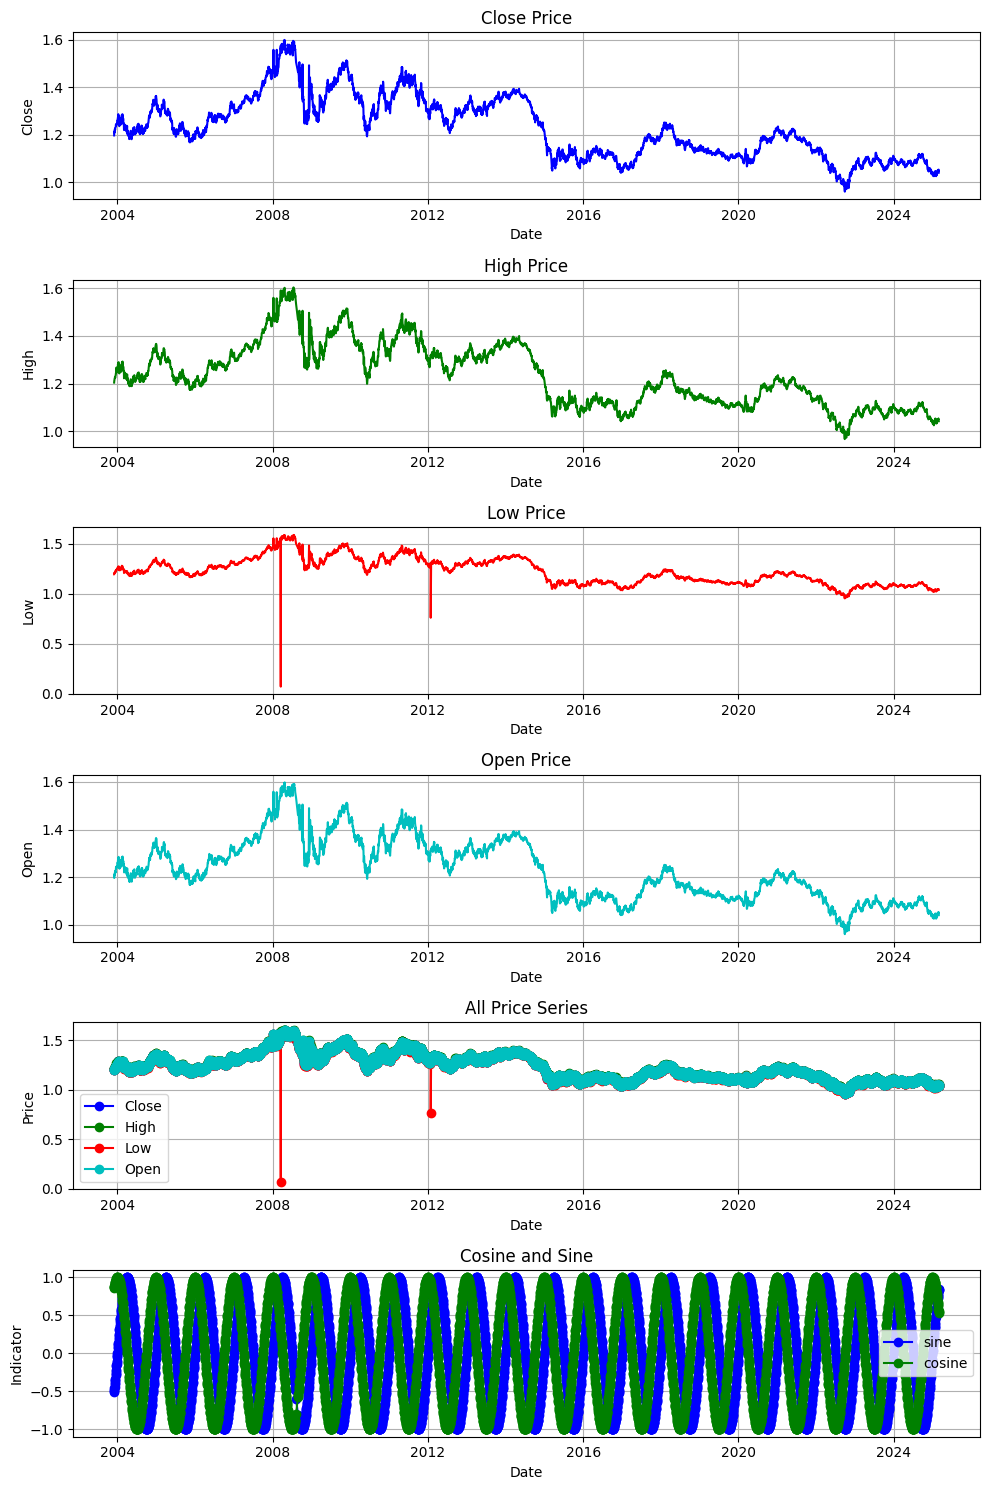

In [163]:
# Create subplots
fig, axs = plt.subplots(6, 1, figsize=(10, 15))

# Plot each time series
axs[0].plot(df['Date'], df['Close'], label='Close', color='b')
axs[0].set_title('Close Price')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Close')
axs[0].grid(True)

axs[1].plot(df['Date'], df['High'], label='High', color='g')
axs[1].set_title('High Price')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('High')
axs[1].grid(True)

axs[2].plot(df['Date'], df['Low'], label='Low', color='r')
axs[2].set_title('Low Price')
axs[2].set_xlabel('Date')
axs[2].set_ylabel('Low')
axs[2].grid(True)

axs[3].plot(df['Date'], df['Open'], label='Open', color='c')
axs[3].set_title('Open Price')
axs[3].set_xlabel('Date')
axs[3].set_ylabel('Open')
axs[3].grid(True)

# Plot the entire dataframe for reference
axs[4].plot(df['Date'], df['Close'], label='Close', color='b', linestyle='-', marker='o')
axs[4].plot(df['Date'], df['High'], label='High', color='g', linestyle='-', marker='o')
axs[4].plot(df['Date'], df['Low'], label='Low', color='r', linestyle='-', marker='o')
axs[4].plot(df['Date'], df['Open'], label='Open', color='c', linestyle='-', marker='o')
axs[4].set_title('All Price Series')
axs[4].set_xlabel('Date')
axs[4].set_ylabel('Price')
axs[4].legend()
axs[4].grid(True)

axs[5].plot(df['Date'], df['sine'], label='sine', color='b', linestyle='-', marker='o')
axs[5].plot(df['Date'], df['cosine'], label='cosine', color='g', linestyle='-', marker='o')
axs[5].set_title('Cosine and Sine')
axs[5].set_xlabel('Date')
axs[5].set_ylabel('Indicator')
axs[5].legend()
axs[5].grid(True)

# Adjust the layout
plt.tight_layout()
plt.show()


In [164]:
full_dataframe_size = len(df)
train_dataframe_size = int(full_dataframe_size * prop)

train_dataframe = df[:train_dataframe_size]
test_dataframe = df[train_dataframe_size-seq_length:] # we take the last seq_length of the train dataset to start testing at the start of the test dataset. 
#these seq_length values wont be infered (see SequenceDataset class)

In [165]:
class SequenceDataset(Dataset):
    """
    Dataset for time series data
    target is a float
    input is a vector of size nb_features*seq_length + 1 : it contains the features of the previous seq_length days and the open price of the current day
    """
    def __init__(self, dataframe, seq_length, target, features):
        self.dataframe = dataframe
        self.seq_length = seq_length
        self.target = target
        self.features = features

        self.x = torch.tensor(self.dataframe[self.features].values, dtype=torch.float32)
        self.y = torch.tensor(self.dataframe[self.target].values, dtype=torch.float32)

        super().__init__()

    def __len__(self):
        return len(self.dataframe) - self.seq_length
    
    def __getitem__(self, idx):
        df_idx = idx + self.seq_length # we start reading the dataframe at idx + seq_length to ensure we can always read seq_length days before the current day

        x = self.x[df_idx - self.seq_length:df_idx]
        x = x.flatten()
        opentoday = self.x[df_idx][0]
        x = torch.cat((x, opentoday.view(-1)), 0)
        y = self.y[df_idx]

        return x, y

In [166]:
train_dataset = SequenceDataset(train_dataframe, seq_length, target, features)
test_dataset = SequenceDataset(test_dataframe, seq_length, target, features)
full_dataset = SequenceDataset(df, seq_length, target, features)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

# Testing and plotting functions

In [167]:
def print_mse(mse, message) :

    display(Markdown(f'# <span style="font-size: 24px;">{message} : {mse}</span>'))

In [168]:
def infer(model, loader):
    model.eval()
    y_pred = []
    y_true = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            
            preds = model(x)
            
            # Store predictions and labels
            y_pred.append(preds)
            y_true.append(y)
    
    y_pred = torch.cat(y_pred, dim=0)
    y_true = torch.cat(y_true, dim=0)
    
    return y_pred, y_true

In [169]:
def plot_time_series(pred, true, start, end, title,vlinesplit=None):
    plt.plot(pred[start:end], label='Prediction', color='r')
    plt.plot(true[start:end], label='True', color='b')
    if vlinesplit is not None:
        plt.axvline(x=vlinesplit, color='g', linestyle='--', label='Testing start')
    plt.title(title)
    plt.legend()
    plt.show()

def plot_full_time_series(pred, true, title) :
    end = len(df) - seq_length
    vlinesplit = train_dataframe_size - seq_length
    plot_time_series(pred, true, 0, end, title, vlinesplit=vlinesplit)

def plot_multiple_time_series(preds, true, start, end, title, labels, vlinesplit=None): 
    colors = ['r', 'g']
    for i in range(len(preds)):
        plt.plot(preds[i][start:end], label=labels[i], color=colors[i])
    plt.plot(true[start:end], label='True', color='b')
    if vlinesplit is not None:    
        plt.axvline(x=vlinesplit, color='g', linestyle='--', label='Testing start')
    plt.title(title)
    plt.legend()
    plt.show()


In [170]:
def plot_loss(loss_per_epoch, title, remove_first = False):
    x = range(1, len(loss_per_epoch) + 1)

    if remove_first :
        x = range(2, len(loss_per_epoch) + 1)
        loss_per_epoch = loss_per_epoch[1:]

    plt.plot(x, loss_per_epoch)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.show()

def plot_losses(train_losses, test_losses, title, remove_first = False, train_lv_mse = None, test_lv_mse = None):
    x = range(1, len(train_losses) + 1)

    if remove_first :
        x = range(2, len(train_losses) + 1)
        train_losses = train_losses[1:]
        test_losses = test_losses[1:]

    plt.plot(x, train_losses, label='Train')
    plt.plot(x, test_losses, label='Test')

    if train_lv_mse is not None and test_lv_mse is not None:
        plt.hlines(train_lv_mse, x[0], x[-1], colors='black', linestyles='dashed', label='Train LV')
        plt.hlines(test_lv_mse, x[0], x[-1], colors='grey', linestyles='dashed', label='Test LV')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.show()

In [171]:
def computeMSE(pred, true):
    mse = nn.MSELoss()
    return mse(pred, true)

# Training function

In [172]:
def train(model, train_loader, test_loader, optimizer, loss_func, EPOCHS, scheduler=None):
    train_losses = []
    test_losses = []

    for epoch in tqdm(range(EPOCHS)):

        model.train()
        epoch_train_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            y_pred = model(x)
            loss = loss_func(y_pred, y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        train_losses.append(epoch_train_loss / len(train_loader)) # len(train_loader) is the number of batches

        if scheduler is not None:
            scheduler.step()
        model.eval()
        with torch.no_grad():

            epoch_test_loss = 0

            for x, y in test_loader:
                y_pred = model(x)
                loss = loss_func(y_pred, y)
                epoch_test_loss += loss.item()
        test_losses.append(epoch_test_loss / len(test_loader))

        if epoch > 0 :
            mlflow.log_metric("train_loss", train_losses[-1], step=epoch)
            mlflow.log_metric("test_loss", test_losses[-1], step=epoch)

    return train_losses, test_losses

# Models definition

### Last value

In [173]:
class LastValue(nn.Module):
    def forward(self, x):
        return x[:, -2] # -1 is the open of today, -2 is the close of yesterday

In [174]:
last_value = LastValue()

pred_lv_test, true_lv_test = infer(last_value, test_loader)
pred_lv_train, true_lv_train = infer(last_value, train_loader)

test_lv_mse = computeMSE(pred_lv_test, true_lv_test)
train_lv_mse = computeMSE(pred_lv_train, true_lv_train)

print_mse(train_lv_mse, "Last value train MSE")
print_mse(test_lv_mse, "Last value test MSE")

# <span style="font-size: 24px;">Last value train MSE : 0.00010077345359604806</span>

# <span style="font-size: 24px;">Last value test MSE : 2.503290852473583e-05</span>

### LSTM

In [175]:
class ClassicalLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.input_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.forget_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.output_gate = nn.Linear(input_size + hidden_size, hidden_size)
        self.state_gate = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, hc):
        """
        x shape : (batch_size, input_size)
        h shape : (batch_size, hidden_size)
        c shape : (batch_size, hidden_size)
        """
        h, c = hc
        xh = torch.cat((x, h), 1)

        input_value = torch.sigmoid(self.input_gate(xh))
        forget_value = torch.sigmoid(self.forget_gate(xh))
        output_value = torch.sigmoid(self.output_gate(xh))
        state_value = torch.tanh(self.state_gate(xh))

        newc = forget_value * c + input_value * state_value
        newh = output_value * torch.tanh(newc)

        return newh, newc # newh shape : (batch_size, hidden_size), newc shape : (batch_size, hidden_size)
    
class ClassicalLSTM(nn.Module):
    def __init__(self, num_features, hidden_size, device, seq_length):
        super().__init__()
        self.num_features = num_features
        self.hidden_size = hidden_size
        self.device = device
        self.seq_length = seq_length
        
        self.cell = ClassicalLSTMCell(self.num_features, hidden_size)
        self.finalLinear = nn.Linear(hidden_size + 1, 1)

    def forward(self, x): # x shape : (batch_size, seq_length*num_features+1)
        opentoday = x[:, -1] # opentoday shape : (batch_size, 1)
        opentoday = opentoday.reshape(-1, 1)

        x = x[:, :-1] # x shape : (batch_size, seq_length*num_features)
        x = x.reshape(-1, self.seq_length, self.num_features) # x shape : (batch_size, seq_length, num_features)

        batch_size = x.size(0)

        h = torch.zeros(batch_size, self.hidden_size, dtype=torch.float32, device=self.device)
        c = torch.zeros(batch_size, self.hidden_size, dtype=torch.float32, device=self.device)

        for i in range(self.seq_length):
            h, c = self.cell(x[:,i,:], (h, c)) # h shape : (batch_size, hidden_size), c shape : (batch_size, hidden_size)

        a = torch.cat((h, opentoday), 1) # a shape : (batch_size, hidden_size + 1)
        a = self.finalLinear(a) # a shape : (batch_size, 1)
        return a.flatten()

In [176]:
num_features = len(features)

lstm = ClassicalLSTM(num_features, hidden_size, device, seq_length)

In [177]:
x, y = next(iter(train_loader))

print(x.shape)
print(y.shape)

pred = lstm(x)
print(pred.shape)

torch.Size([16, 19])
torch.Size([16])
torch.Size([16])


# Training

In [178]:
optimizer = torch.optim.Adam(lstm.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
loss_func = nn.MSELoss()

In [179]:
pred, true = infer(lstm, test_loader)
mse = computeMSE(pred, true)

print_mse(mse, "Test MSE before training")

# <span style="font-size: 24px;">Test MSE before training : 1.3001387119293213</span>

In [180]:
train_losses, test_losses = train(lstm, train_loader, test_loader, optimizer, loss_func, EPOCHS, scheduler=None)

100%|██████████| 20/20 [00:45<00:00,  2.28s/it]


In [181]:
pred_test, true_test = infer(lstm, test_loader)
mse = computeMSE(pred_test, true_test)

pred_train, true_train = infer(lstm, train_loader)
mse_train = computeMSE(pred_train, true_train)

print_mse(mse_train, "Train MSE after training")
print_mse(mse, "Test MSE after training")

# <span style="font-size: 24px;">Train MSE after training : 0.00012894759129267186</span>

# <span style="font-size: 24px;">Test MSE after training : 3.6632376577472314e-05</span>

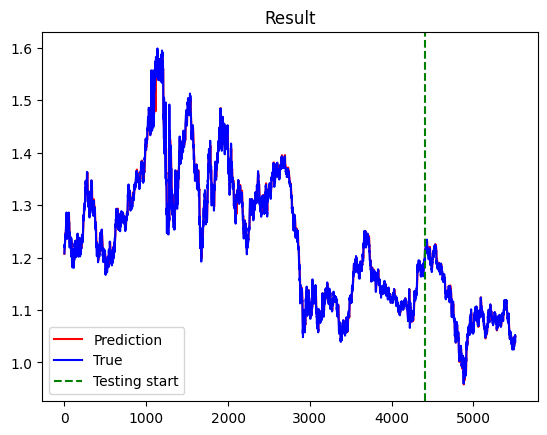

In [182]:
pred, true = infer(lstm, full_loader)

plot_full_time_series(pred, true, "Result")

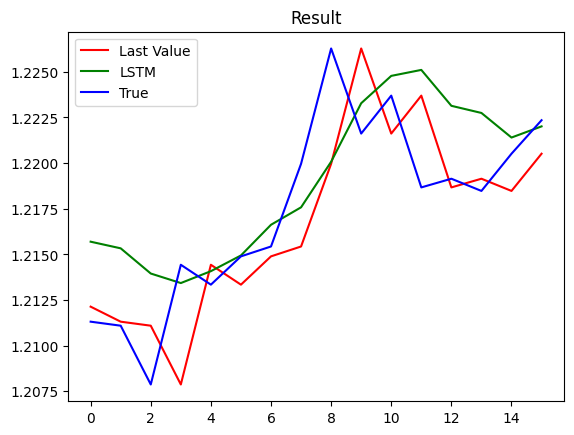

In [183]:
plot_multiple_time_series([pred_lv_test, pred_test], true_test, 0, 16, "Result", ["Last Value", "LSTM"])

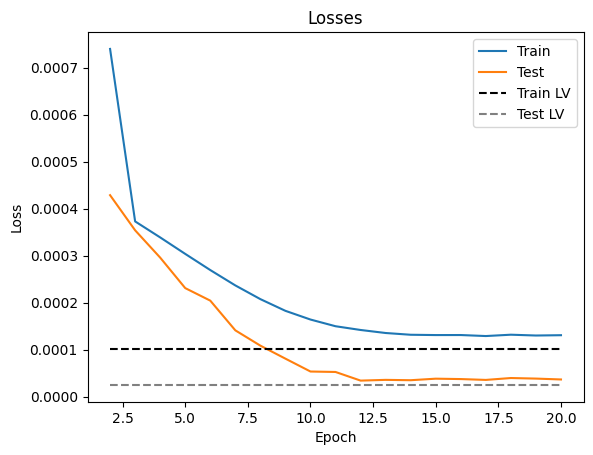

In [184]:
plot_losses(train_losses, test_losses, "Losses", remove_first=True, train_lv_mse=train_lv_mse, test_lv_mse=test_lv_mse)

In [185]:
mlflow.end_run()